[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hb-cam/Retail-Forecasting-Talk/blob/main/notebooks/Retail_Forecast.ipynb)

In [ ]:
import os
if 'google.colab' in str(get_ipython()):
    !pip install pandas numpy matplotlib statsmodels requests python-dotenv
    !git clone https://github.com/hb-cam/Retail-Forecasting-Talk.git
    os.chdir('Retail-Forecasting-Talk/notebooks')

# The Art of Forecast Model Generation

This notebook demonstrates the **iterative, diagnostic-driven process** of building a regression forecast — what we call the "art" of model generation. Rather than blindly fitting a model and reporting R², we:

1. Fit a naïve model
2. Run a comprehensive diagnostic sweep
3. Deep-dive into each violation
4. Correct inference and validate out-of-sample

We use a **synthetic Data Generating Process (DGP)** so every pathology is controlled and narrated. The diagnostics module `RegressionDiagnostics` (v2) handles the heavy lifting.

**Sections:**
1. Introduction
2. The Data Generating Process
3. Train/Test Split
4. Naïve OLS — First Pass
5. Diagnostic Sweep
6. Heteroskedasticity
7. Autocorrelation
8. Collinearity (VIF)
9. Joint F-Test: Don't Drop That Variable
10. Influence & Outliers
11. Specification (RESET)
12. Corrected Model — HAC Inference
13. Out-of-Sample Comparison
14. Decision Impact Summary
15. Implications

In [163]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import (
    het_breuschpagan,
    het_white,
    linear_reset,
)
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

# Ensure src/ is importable
sys.path.insert(0, str(Path.cwd().parent / "src"))

from regression_dclass.regression_dclass_v2 import RegressionDiagnostics

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## 2. The Data Generating Process

We build a synthetic dataset with **three controlled pathologies**:

1. **Collinearity** — x1 and x3 share a latent common factor z, creating VIF ≈ 5. Both carry genuine signal, but collinearity inflates their individual standard errors.
2. **Heteroskedasticity** — Error variance grows linearly with x1. Observations with high x1 are noisier.
3. **AR(1) autocorrelation** — Errors follow ε_t = 0.6·ε_{t-1} + u_t. This mimics persistent shocks common in economic time series.

Additionally, x3 undergoes a **structural shift** (+1.5) in the 52-period holdout — simulating real-world regime change where a predictor's unique component diverges. Two **discrete shocks** (+3.0 each, lasting 5 periods) are layered on top, representing the kind of transient disruptions (policy changes, market events) that routinely occur in practice. This is exactly the scenario where dropping a "borderline" collinear variable costs you out-of-sample accuracy.

**True model:** y = 25 + 2.0·x1 − 1.5·x2 + 0.65·x3 + 1.2·x4 − 0.5·x5 + 0.3·x6 + ε

In [164]:
# ── Data Generating Process ──────────────────────────────────────────
np.random.seed(42)
n = 362
n_train = 310  # 310 train + 52 test holdout

# Latent common factor (not observed — drives collinearity between x1, x3)
z = np.random.normal(12, 1, n)

# Predictors
x1 = z + np.random.normal(0, 0.3, n)   # shares z with x3 → VIF ≈ 5
x2 = np.random.normal(0, 1, n) + 12    # independent
x3 = z + np.random.normal(0, 0.3, n)   # shares z with x1 → VIF ≈ 5
x4 = np.random.normal(0, 1, n) + 12    # independent
x5 = np.random.normal(0, 1, n) + 12    # independent
x6 = 0.7 * x2 + 0.3 * x4 + np.random.normal(0, 0.5, n)  # moderate VIF ≈ 3

# Structural shift: x3 diverges from x1 in the holdout period.
# Simulates real-world regime change where a predictor's unique
# component becomes more pronounced — exactly the scenario where
# dropping a collinear variable costs you OOS accuracy.
x3[n_train:] += 1.5

# Discrete shocks: two transient disruptions during the holdout,
# representing the kind of real-world events (policy changes, market
# shifts) that a model without x3 cannot track.
x3[322:327] += 3.0
x3[342:347] += 3.0

X = np.column_stack([x1, x2, x3, x4, x5, x6])
predictor_names = ["x1", "x2", "x3", "x4", "x5", "x6"]

# True coefficients
beta_true = np.array([25, 2.0, -1.5, 0.65, 1.2, -0.5, 0.3])

# Heteroskedastic AR(1) errors
sigma_base = 3.0
sigma_x = sigma_base * np.maximum(0.3 * (x1 - 10), 0.1)  # linear in x1

rho = 0.6  # AR(1) coefficient
rng_err = np.random.RandomState(88)
eps = np.zeros(n)
eps[0] = rng_err.normal(0, sigma_x[0])
for t in range(1, n):
    eps[t] = rho * eps[t - 1] + rng_err.normal(0, sigma_x[t])

# Observed outcome
X_const = sm.add_constant(X)
y = X_const @ beta_true + eps

print(f"n = {n} ({n_train} train / {n - n_train} test)")
print(f"y: mean={y.mean():.1f}, std={y.std():.1f}")
print(f"x1 range: [{x1.min():.1f}, {x1.max():.1f}]")

n = 362 (310 train / 52 test)
y: mean=50.8, std=4.0
x1 range: [9.2, 16.4]


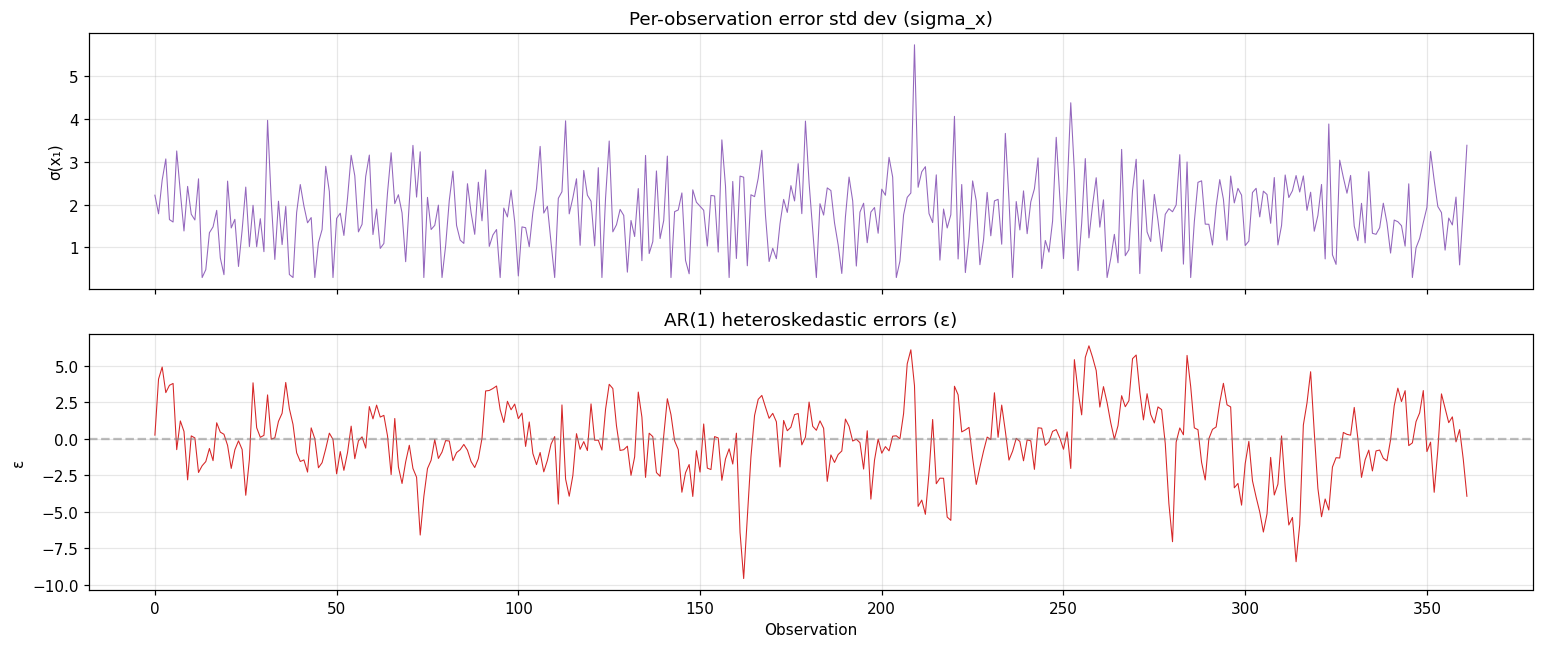

In [165]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(sigma_x, linewidth=0.7, color="tab:purple")
axes[0].set_ylabel("σ(x₁)")
axes[0].set_title("Per-observation error std dev (sigma_x)")

axes[1].plot(eps, linewidth=0.7, color="tab:red")
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[1].set_ylabel("ε")
axes[1].set_xlabel("Observation")
axes[1].set_title("AR(1) heteroskedastic errors (ε)")

fig.tight_layout()
plt.show()

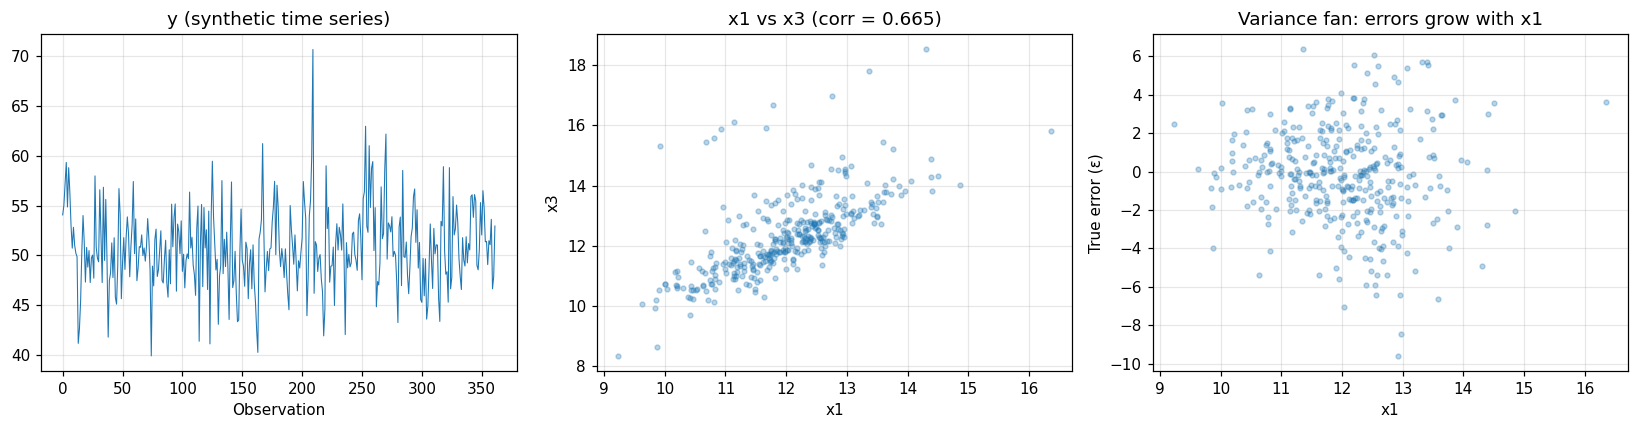

In [166]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# y time series
axes[0].plot(y, linewidth=0.7)
axes[0].set_title("y (synthetic time series)")
axes[0].set_xlabel("Observation")

# x1 vs x3 scatter (collinear pair)
axes[1].scatter(x1, x3, alpha=0.3, s=10)
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x3")
axes[1].set_title(f"x1 vs x3 (corr = {np.corrcoef(x1, x3)[0,1]:.3f})")

# Residual variance fan (true errors vs x1)
axes[2].scatter(x1, eps, alpha=0.3, s=10)
axes[2].set_xlabel("x1")
axes[2].set_ylabel("True error (ε)")
axes[2].set_title("Variance fan: errors grow with x1")

fig.tight_layout()
plt.show()

## 3. Train/Test Split

We hold out the **last 52 observations** as the test set — a realistic holdout for weekly or monthly data spanning roughly one year of weekly observations. The model is fit on the first 310 observations and evaluated on the unseen 52.

Train: 310 obs  |  Test: 52 obs


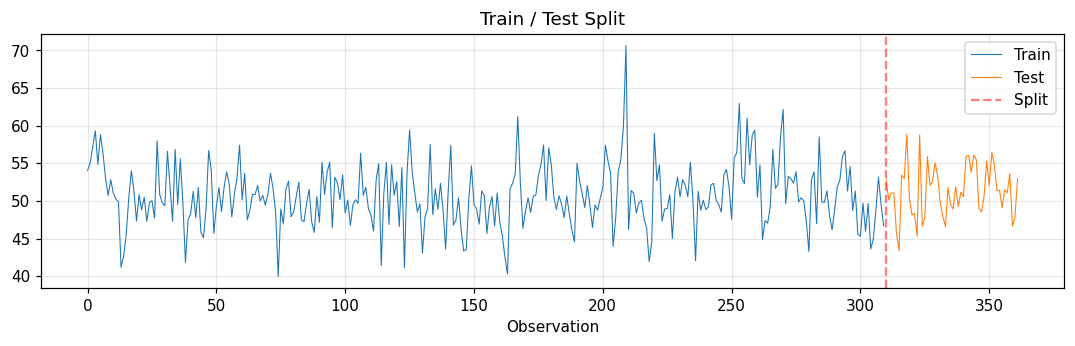

In [167]:
X_train, X_test = X_const[:n_train], X_const[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

print(f"Train: {n_train} obs  |  Test: {n - n_train} obs")

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(range(n_train), y_train, label="Train", linewidth=0.7)
ax.plot(range(n_train, n), y_test, label="Test", linewidth=0.7, color="tab:orange")
ax.axvline(n_train, color="red", linestyle="--", alpha=0.5, label="Split")
ax.legend()
ax.set_title("Train / Test Split")
ax.set_xlabel("Observation")
plt.show()

## 4. Naïve OLS — First Pass

We fit OLS with **default (non-robust) standard errors** on the training data. The summary looks good — R² is reasonable and most coefficients are "significant." But are we done?

In [168]:
fit_naive = sm.OLS(y_train, X_train).fit()  # standard (non-robust) SEs
print(fit_naive.summary())
print(f"\nR² = {fit_naive.rsquared:.4f}  |  Adj R² = {fit_naive.rsquared_adj:.4f}")
print("\n⚠ R² looks reasonable. Are we done? Let's check the diagnostics...")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.653
Model:                            OLS   Adj. R-squared:                  0.646
Method:                 Least Squares   F-statistic:                     95.18
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           9.90e-67
Time:                        13:05:21   Log-Likelihood:                -715.69
No. Observations:                 310   AIC:                             1445.
Df Residuals:                     303   BIC:                             1472.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.6427      3.539      6.963      0.0

## 5. Diagnostic Sweep

We run the full `RegressionDiagnostics` suite on the training data. This produces:
- Heteroskedasticity tests (Breusch–Pagan, White)
- Autocorrelation tests (Durbin–Watson, Ljung–Box)
- Collinearity diagnostics (VIF)
- Influence analysis (Cook's D, leverage)
- Specification test (Ramsey RESET)
- ACF/PACF plots

The `report()` output summarizes all findings and recommends next actions.

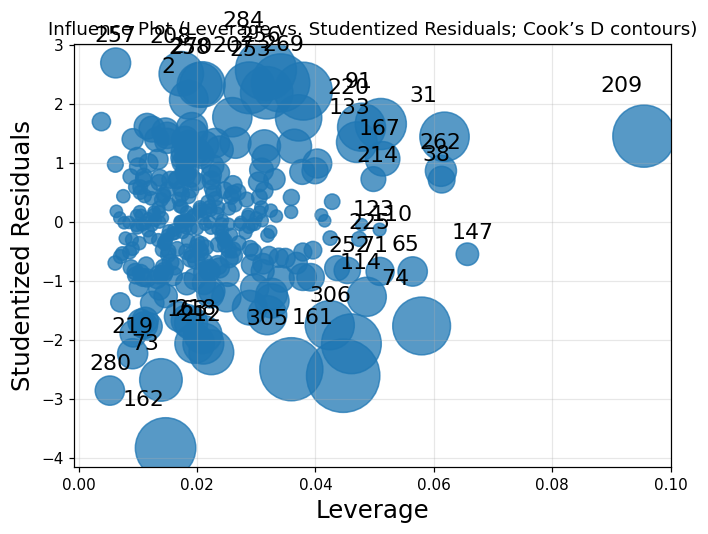

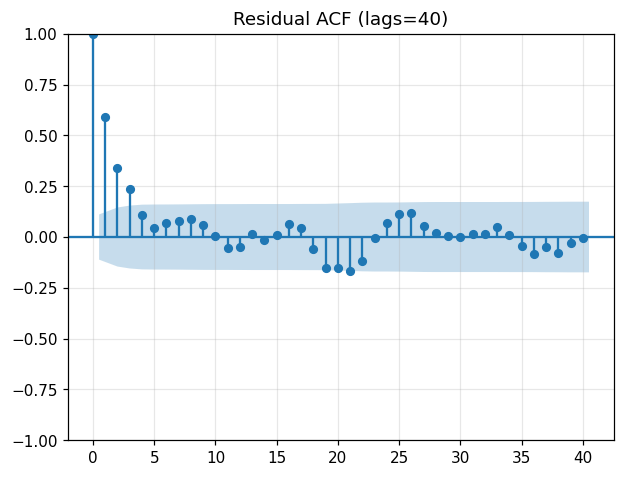

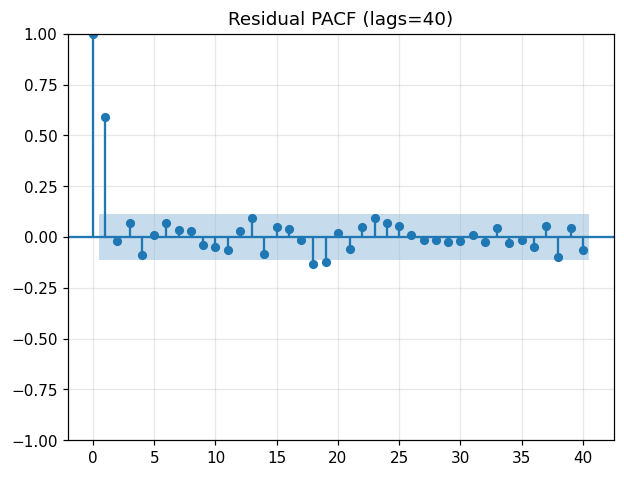

In [169]:
# Run full diagnostics (uses HAC internally for robust inference)
diag = RegressionDiagnostics(
    X_train[:, 1:],  # drop constant — RegressionDiagnostics adds it
    y_train,
    add_const=True,
)
res = diag.run(make_plots=True)
plt.show()

In [170]:
print(diag.report())

MODEL DIAGNOSTICS SUMMARY
Sample size (n)=310, parameters (p)=7  |  HAC: maxlags=5, kernel=bartlett

Performance (in-sample)
  RMSE=2.434469  |  MAE=1.851138  |  MAPE=3.651%

Model Risk Tests
  Specification (Ramsey RESET, power=2): p=0.2387 (alpha=0.05)
  OVB candidate test: not run (provide Z_ovb to enable).

Error Structure Tests
  Heteroskedasticity: Breusch–Pagan p=0.0074; White p=0.1288 (alpha=0.05)
  Autocorrelation: Durbin–Watson=0.811; Ljung–Box p-values:
  - Lag  1: p=1.14e-25
  - Lag  5: p=2.05e-34
  - Lag 10: p=2.45e-32
  - Lag 20: p=6.88e-31

Collinearity (VIF)
  Threshold=5.0; flagged=2
  - Predictor 1: VIF=5.21 ***
  - Predictor 2: VIF=2.90
  - Predictor 3: VIF=5.19 ***
  - Predictor 4: VIF=1.38
  - Predictor 5: VIF=1.02
  - Predictor 6: VIF=3.26

Stability / Influence
  Cook’s distance: threshold=0.012903; flagged=22
  Top Cook’s distance observations (index, D, leverage, rstudent):
    - 161: D=0.044716, h=0.044681, r=-2.612
    - 305: D=0.032746, h=0.035924, r=-2.502


## 6. Heteroskedasticity

The Breusch–Pagan test rejects strongly — error variance is **not constant**. The residual-vs-fitted plot confirms a variance fan. This means:

- Standard errors are **wrong** → t-statistics are wrong → inference is unreliable
- OLS coefficients are still unbiased, but we can't trust the p-values

**Fix:** Use HAC (Newey–West) standard errors, which are robust to both heteroskedasticity and autocorrelation.

Breusch–Pagan: LM = 17.58, p = 0.007368
White:         LM = 35.41, p = 0.128761


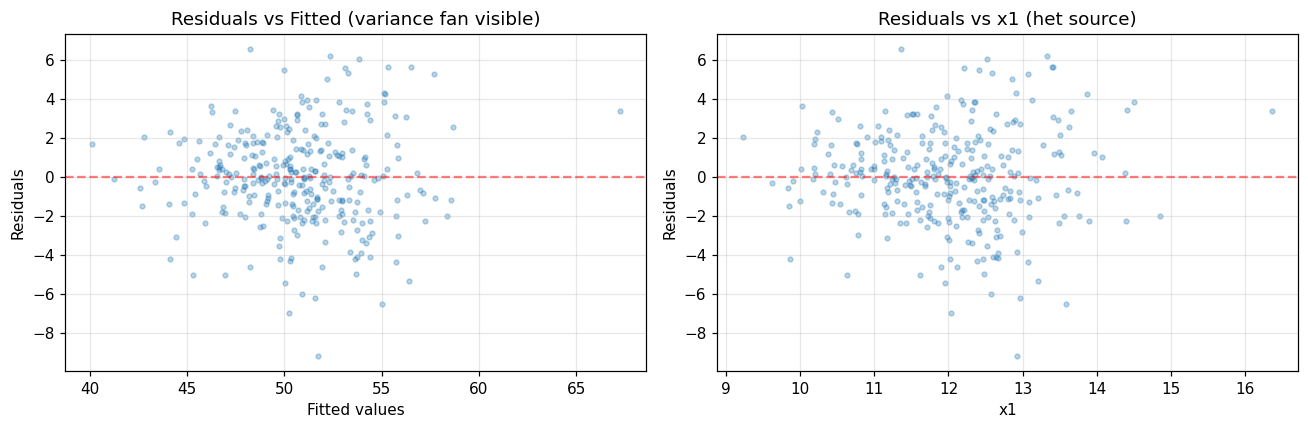

In [171]:
resid = fit_naive.resid
bp_lm, bp_p, _, _ = het_breuschpagan(resid, X_train)
w_lm, w_p, _, _ = het_white(resid, X_train)

print(f"Breusch–Pagan: LM = {bp_lm:.2f}, p = {bp_p:.6f}")
print(f"White:         LM = {w_lm:.2f}, p = {w_p:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(fit_naive.fittedvalues, resid, alpha=0.3, s=10)
axes[0].axhline(0, color="red", linestyle="--", alpha=0.5)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted (variance fan visible)")

axes[1].scatter(X_train[:, 1], resid, alpha=0.3, s=10)  # x1 is column 1
axes[1].axhline(0, color="red", linestyle="--", alpha=0.5)
axes[1].set_xlabel("x1")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs x1 (het source)")
fig.tight_layout()
plt.show()

## 7. Autocorrelation

The Durbin–Watson statistic is well below 2, and Ljung–Box rejects at all lags. This confirms **positive serial correlation** in the errors (our DGP has ρ = 0.6).

In practice, autocorrelation often signals:
- Missing dynamics (lagged y or lagged X)
- Omitted variable bias
- Structural breaks

HAC standard errors correct inference for autocorrelation too, but they **don't fix the DGP** — the errors are still correlated.

Durbin–Watson: 0.8108  (< 2 → positive autocorrelation)

Ljung–Box tests:
       lb_stat     lb_pvalue
1   109.691544  1.144892e-25
4   167.242234  4.085912e-35
12  176.865121  1.875337e-31


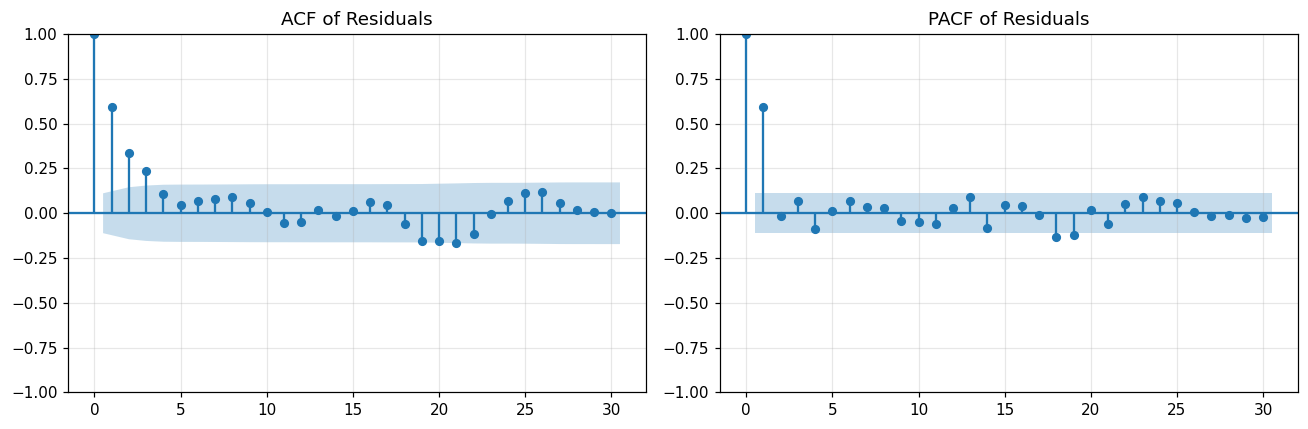

In [172]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

dw = durbin_watson(resid)
lb = acorr_ljungbox(resid, lags=[1, 4, 12], return_df=True)

print(f"Durbin–Watson: {dw:.4f}  (< 2 → positive autocorrelation)")
print("\nLjung–Box tests:")
print(lb.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(resid, lags=30, ax=axes[0])
axes[0].set_title("ACF of Residuals")
plot_pacf(resid, lags=30, ax=axes[1], method="ywm")
axes[1].set_title("PACF of Residuals")
fig.tight_layout()
plt.show()

## 8. Collinearity (VIF)

Variance Inflation Factors measure how much collinearity inflates the variance of each coefficient estimate. Values above 5–8 signal problematic collinearity.

x1 and x3 both flag — they share a common latent factor. The individual HAC t-test on x3 gives p ≈ 0.09, which **fails** at the 5% significance level and is borderline at 10%. A common reaction: *"x3 isn't significant — drop it."*

**That would be a mistake.** The next section shows why.

In [173]:
# Fit with HAC for correct inference
maxlags = int(n_train ** 0.25)
fit_hac = sm.OLS(y_train, X_train).fit(
    cov_type="HAC", cov_kwds={"maxlags": maxlags}
)

# VIF (computed on design matrix including constant)
print("Variance Inflation Factors:")
print("-" * 35)
for i, name in enumerate(predictor_names):
    vif = variance_inflation_factor(X_train, i + 1)  # +1 to skip constant
    flag = " ⚠ COLLINEAR" if vif > 5 else ""
    print(f"  {name}: VIF = {vif:.2f}{flag}")

print(f"\nHAC p-value for x3 (individual): {fit_hac.pvalues[3]:.4f}")
print("→ Not significant at 5%. Borderline at 10%. Drop x3?")

Variance Inflation Factors:
-----------------------------------
  x1: VIF = 5.21 ⚠ COLLINEAR
  x2: VIF = 2.90
  x3: VIF = 5.19 ⚠ COLLINEAR
  x4: VIF = 1.38
  x5: VIF = 1.02
  x6: VIF = 3.26

HAC p-value for x3 (individual): 0.0880
→ Not significant at 5%. Borderline at 10%. Drop x3?


## 9. Joint F-Test: Don't Drop That Variable

This is the key insight. Collinearity inflates **individual** standard errors, making t-tests lose power. But a **joint test** on the collinear group uses the full covariance structure and can reject even when individual tests don't.

We demonstrate two tests:

**Test A:** Joint Wald test — H₀: β₁ = β₃ = 0 (both collinear predictors are zero)

**Test B:** Unrestricted vs restricted — does dropping x3 significantly worsen the model?

Both tests use HAC-robust covariance, so results are valid despite heteroskedasticity and autocorrelation.

In [174]:
# ── Test A: Joint Wald test on {x1, x3} ─────────────────────────────
# H₀: β_x1 = β_x3 = 0  (both collinear predictors are jointly zero)
R = np.zeros((2, 7))  # 7 params: const + 6 predictors
R[0, 1] = 1  # x1 (column 1 in design matrix)
R[1, 3] = 1  # x3 (column 3 in design matrix)
wald_joint = fit_hac.wald_test(R, use_f=True, scalar=True)

# Individual Wald on x3 alone (for comparison)
R_x3 = np.zeros((1, 7))
R_x3[0, 3] = 1
wald_x3 = fit_hac.wald_test(R_x3, use_f=True, scalar=True)

print("=" * 60)
print("INDIVIDUAL vs JOINT TEST (HAC-robust)")
print("=" * 60)
print("\nIndividual Wald on x3:")
print(f"  F = {wald_x3.fvalue:.2f},  p = {wald_x3.pvalue:.4f}")
print(f"  → {'Reject' if wald_x3.pvalue < 0.05 else 'FAIL TO REJECT'} at α = 0.05")

print("\nJoint Wald on {x1, x3}:")
print(f"  F = {wald_joint.fvalue:.1f},  p = {wald_joint.pvalue:.2e}")
print(f"  → {'REJECT' if wald_joint.pvalue < 0.05 else 'Fail to reject'} at α = 0.05")

print(f"\n→ Individual test says x3 is not significant (p = {wald_x3.pvalue:.2f}).")
print("→ Joint test says {x1, x3} are jointly HIGHLY significant.")
print("→ Collinearity inflates individual SEs but the joint distribution")
print("  shows both variables carry signal. Don't drop x3!")

INDIVIDUAL vs JOINT TEST (HAC-robust)

Individual Wald on x3:
  F = 2.91,  p = 0.0890
  → FAIL TO REJECT at α = 0.05

Joint Wald on {x1, x3}:
  F = 235.0,  p = 2.36e-62
  → REJECT at α = 0.05

→ Individual test says x3 is not significant (p = 0.09).
→ Joint test says {x1, x3} are jointly HIGHLY significant.
→ Collinearity inflates individual SEs but the joint distribution
  shows both variables carry signal. Don't drop x3!


In [175]:
# ── Test B: Unrestricted vs Restricted model ─────────────────────────
# Restricted model: drop x3 (column 3 in design matrix)
keep_cols = [0, 1, 2, 4, 5, 6]  # const, x1, x2, x4, x5, x6
X_train_r = X_train[:, keep_cols]

fit_restricted = sm.OLS(y_train, X_train_r).fit(
    cov_type="HAC", cov_kwds={"maxlags": maxlags}
)

# Show OVB: how x1's coefficient shifts when x3 is dropped
print("=" * 60)
print("OMITTED VARIABLE BIAS (OVB) EVIDENCE")
print("=" * 60)
print(f"\nx1 coefficient (unrestricted): {fit_hac.params[1]:+.4f}")
print(f"x1 coefficient (restricted):   {fit_restricted.params[1]:+.4f}")
shift = fit_restricted.params[1] - fit_hac.params[1]
print(f"Shift:                          {shift:+.4f}")
print(f"\nTrue β₁ = 2.0. Dropping x3 biases x1 upward by ~{shift:.2f}.")
print("x1 absorbs the shared signal from z but loses x3's unique component.")
print("\n→ Dropping x3 introduces OVB, biasing the remaining coefficients.")

OMITTED VARIABLE BIAS (OVB) EVIDENCE

x1 coefficient (unrestricted): +2.0905
x1 coefficient (restricted):   +2.5172
Shift:                          +0.4267

True β₁ = 2.0. Dropping x3 biases x1 upward by ~0.43.
x1 absorbs the shared signal from z but loses x3's unique component.

→ Dropping x3 introduces OVB, biasing the remaining coefficients.


## 10. Influence & Outliers

Cook's distance identifies observations that disproportionately affect the fitted model. Heteroskedasticity amplifies influence for high-x1 observations (where variance is larger), making influence analysis particularly important here.

Top 5 Cook's Distance observations:
    Obs    Cook D  Leverage  Rstudent
    161    0.0447    0.0447    -2.612
    305    0.0327    0.0359    -2.502
    209    0.0318    0.0955    +1.455
    284    0.0305    0.0316    +2.581
    162    0.0300    0.0147    -3.837


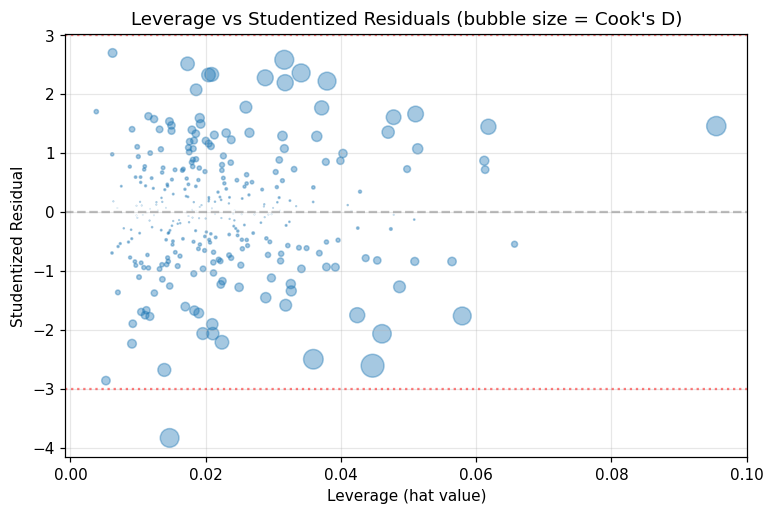

In [176]:
infl = OLSInfluence(fit_naive)
cooks_d = infl.cooks_distance[0]
hat = infl.hat_matrix_diag
rstudent = infl.resid_studentized_external

# Top 5 influential observations
top5 = np.argsort(cooks_d)[-5:][::-1]
print("Top 5 Cook's Distance observations:")
print(f"  {'Obs':>5s}  {'Cook D':>8s}  {'Leverage':>8s}  {'Rstudent':>8s}")
for idx in top5:
    print(f"  {idx:5d}  {cooks_d[idx]:8.4f}  {hat[idx]:8.4f}  {rstudent[idx]:+8.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(hat, rstudent, s=cooks_d * 5000, alpha=0.4)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.axhline(3, color="red", linestyle=":", alpha=0.5)
ax.axhline(-3, color="red", linestyle=":", alpha=0.5)
ax.set_xlabel("Leverage (hat value)")
ax.set_ylabel("Studentized Residual")
ax.set_title("Leverage vs Studentized Residuals (bubble size = Cook's D)")
plt.show()

## 11. Specification (RESET)

The Ramsey RESET test checks for functional-form misspecification by testing whether powers of the fitted values (ŷ², ŷ³) are significant when added to the model. If RESET rejects, it suggests the linear model is inadequate — perhaps nonlinear terms, interactions, or transformations are needed.

In [177]:
reset = linear_reset(fit_naive, power=3, use_f=True)
print(f"Ramsey RESET: F = {reset.fvalue:.4f}, p = {reset.pvalue:.4f}")

if reset.pvalue > 0.05:
    print("\n→ No strong evidence of functional-form misspecification.")
    print("  The linear model is adequate for this DGP.")
else:
    print("\n→ RESET rejects: consider nonlinear terms or interactions.")

Ramsey RESET: F = 1.2164, p = 0.2978

→ No strong evidence of functional-form misspecification.
  The linear model is adequate for this DGP.


## 12. Corrected Model — HAC Inference

HAC (Newey–West) standard errors are robust to **both** heteroskedasticity and autocorrelation. They don't change the coefficient estimates (β̂ is identical) — they change **how confident we are** in those estimates.

The side-by-side comparison shows which conclusions change when we use correct standard errors.

In [178]:
print("=" * 75)
print("STANDARD vs HAC STANDARD ERRORS")
print("=" * 75)
print(f"\n{'Variable':>8s}  {'Coef':>8s}  {'SE(OLS)':>8s}  {'SE(HAC)':>8s}  "
      f"{'p(OLS)':>8s}  {'p(HAC)':>8s}  {'SE ratio':>8s}")
print("-" * 75)

var_names = ["const"] + predictor_names
for i, nm in enumerate(var_names):
    p_ols = fit_naive.pvalues[i]
    p_hac = fit_hac.pvalues[i]
    se_ratio = fit_hac.bse[i] / fit_naive.bse[i]
    # Suppress SE ratio when both p-values < 0.001 — the ratio is
    # distracting when significance is overwhelming either way
    ratio_str = f"{se_ratio:8.2f}x" if p_ols >= 0.001 or p_hac >= 0.001 else f"{'—':>9s}"
    print(
        f"{nm:>8s}  {fit_naive.params[i]:+8.3f}  {fit_naive.bse[i]:8.3f}  "
        f"{fit_hac.bse[i]:8.3f}  {p_ols:8.4f}  {p_hac:8.4f}  {ratio_str}"
    )

print("\n→ Coefficients are IDENTICAL (HAC doesn't change β̂).")
print("→ SE ratio shown where inference changes meaningfully (p ≥ 0.001 for either test).")

STANDARD vs HAC STANDARD ERRORS

Variable      Coef   SE(OLS)   SE(HAC)    p(OLS)    p(HAC)  SE ratio
---------------------------------------------------------------------------
   const   +24.643     3.539     3.235    0.0000    0.0000          —
      x1    +2.090     0.318     0.265    0.0000    0.0000          —
      x2    -1.563     0.251     0.215    0.0000    0.0000          —
      x3    +0.476     0.319     0.279    0.1363    0.0880      0.88x
      x4    +1.459     0.164     0.142    0.0000    0.0000          —
      x5    -0.550     0.146     0.147    0.0002    0.0002          —
      x6    +0.258     0.290     0.223    0.3749    0.2483      0.77x

→ Coefficients are IDENTICAL (HAC doesn't change β̂).
→ SE ratio shown where inference changes meaningfully (p ≥ 0.001 for either test).


## 13. Out-of-Sample Comparison

Does keeping x3 (as the joint test recommends) actually improve forecasts? We compare the **unrestricted model** (all 6 predictors) against the **restricted model** (x3 dropped) on the 52-period holdout set.

Beyond period-by-period metrics, we measure the **accumulated miss** — the running sum of forecast errors over the holdout. This is the metric that matters in business: if you're systematically off by a small amount each period, the cumulative cost compounds.

If x3 were dropped based on its individual p-value alone, the forecast would suffer — the diagnostic discipline pays off.

OUT-OF-SAMPLE COMPARISON (52 periods)

                    Model      RMSE       MAE      MAPE
------------------------------------------------------------
     Unrestricted (all 6)     2.840     2.168     4.25%
     Restricted (drop x3)     3.056     2.462     4.77%

Dropping x3 worsens RMSE by 0.216 (+7.6%)

ACCUMULATED MISS (sum actual − sum predicted over 52 periods)
  Unrestricted: -9.89
  Restricted:   +42.79
  Gap:          +52.68
→ The structural shift in x3 during the holdout amplifies the cost of omission.


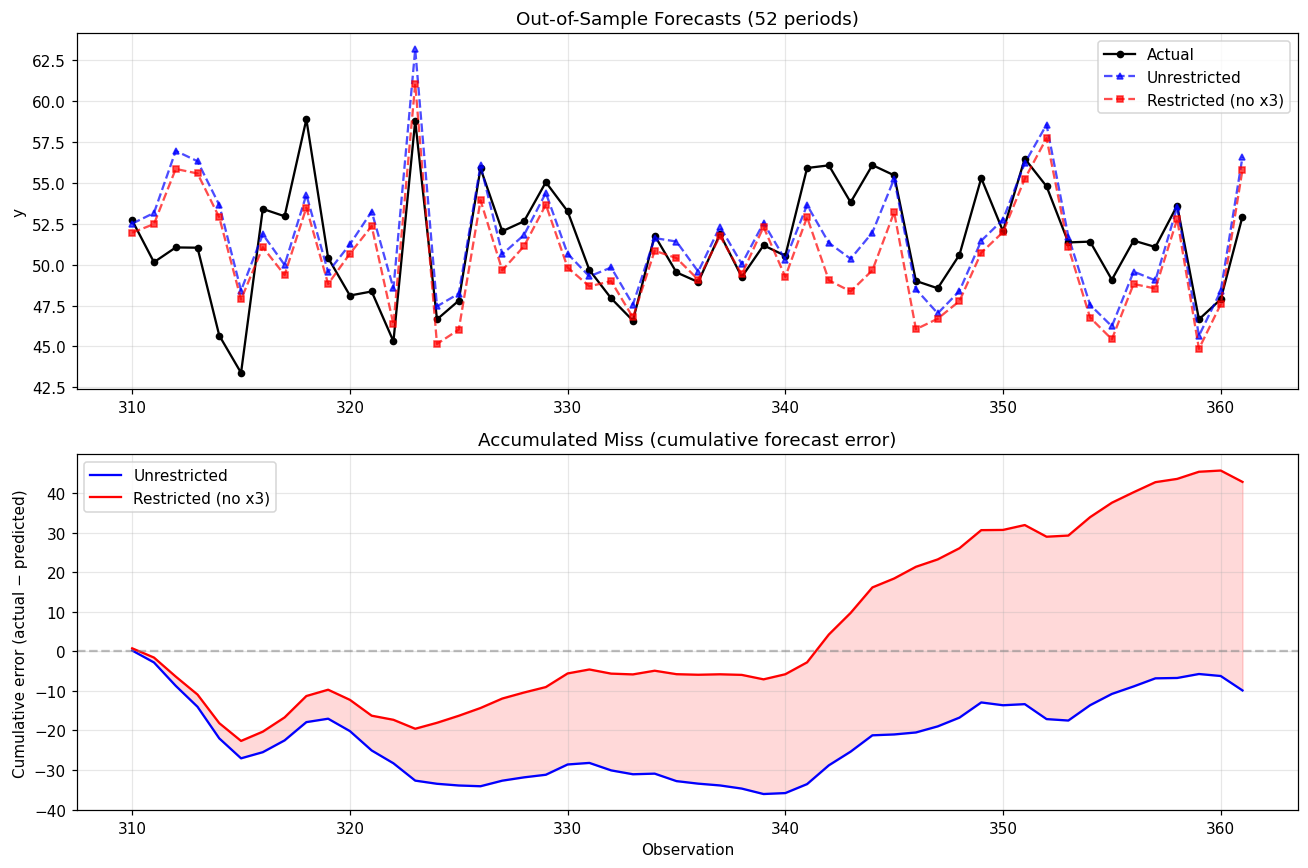

In [179]:
# Unrestricted predictions (all 6 predictors)
y_pred_u = fit_naive.predict(X_test)

# Restricted predictions (x3 dropped)
X_test_r = X_test[:, keep_cols]
fit_restricted_ols = sm.OLS(y_train, X_train_r).fit()
y_pred_r = fit_restricted_ols.predict(X_test_r)

# Period-by-period metrics
n_test = n - n_train

def oos_metrics(y_true, y_pred, label):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"label": label, "RMSE": rmse, "MAE": mae, "MAPE": mape}

m_u = oos_metrics(y_test, y_pred_u, "Unrestricted (all 6)")
m_r = oos_metrics(y_test, y_pred_r, "Restricted (drop x3)")

# Accumulated miss: difference in sums over the full holdout
accum_miss_u = np.sum(y_test) - np.sum(y_pred_u)
accum_miss_r = np.sum(y_test) - np.sum(y_pred_r)
accum_miss_gap = accum_miss_r - accum_miss_u

print("=" * 60)
print(f"OUT-OF-SAMPLE COMPARISON ({n_test} periods)")
print("=" * 60)
print(f"\n{'Model':>25s}  {'RMSE':>8s}  {'MAE':>8s}  {'MAPE':>8s}")
print("-" * 60)
print(f"{m_u['label']:>25s}  {m_u['RMSE']:8.3f}  {m_u['MAE']:8.3f}  {m_u['MAPE']:7.2f}%")
print(f"{m_r['label']:>25s}  {m_r['RMSE']:8.3f}  {m_r['MAE']:8.3f}  {m_r['MAPE']:7.2f}%")
abs_diff = m_r["RMSE"] - m_u["RMSE"]
pct_diff = abs_diff / m_u["RMSE"] * 100
print(f"\nDropping x3 worsens RMSE by {abs_diff:.3f} ({pct_diff:+.1f}%)")

print(f"\nACCUMULATED MISS (sum actual \u2212 sum predicted over {n_test} periods)")
print(f"  Unrestricted: {accum_miss_u:+.2f}")
print(f"  Restricted:   {accum_miss_r:+.2f}")
print(f"  Gap:          {accum_miss_gap:+.2f}")
print("\u2192 The structural shift in x3 during the holdout amplifies the cost of omission.")

# ── Charts ──
fig, axes = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[1, 1])

# Panel 1: Period-by-period forecasts
t_idx = range(n_train, n)
axes[0].plot(t_idx, y_test, "ko-", label="Actual", markersize=4)
axes[0].plot(t_idx, y_pred_u, "b^--", label="Unrestricted", markersize=4, alpha=0.7)
axes[0].plot(t_idx, y_pred_r, "rs--", label="Restricted (no x3)", markersize=4, alpha=0.7)
axes[0].legend()
axes[0].set_title(f"Out-of-Sample Forecasts ({n_test} periods)")
axes[0].set_ylabel("y")

# Panel 2: Cumulative forecast error
cum_err_u = np.cumsum(y_test - y_pred_u)
cum_err_r = np.cumsum(y_test - y_pred_r)
axes[1].plot(t_idx, cum_err_u, "b-", label="Unrestricted", linewidth=1.5)
axes[1].plot(t_idx, cum_err_r, "r-", label="Restricted (no x3)", linewidth=1.5)
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[1].fill_between(t_idx, cum_err_u, cum_err_r, alpha=0.15, color="red")
axes[1].legend()
axes[1].set_title("Accumulated Miss (cumulative forecast error)")
axes[1].set_xlabel("Observation")
axes[1].set_ylabel("Cumulative error (actual \u2212 predicted)")

fig.tight_layout()
plt.show()

## 14. Decision Impact Summary

The sections above walked through each diagnostic in isolation. This table brings it all together — showing what happens when you follow the diagnostics vs when you don't.

Same data, same violations detected. The paths diverge at one decision: **what to do about x3.**

In [180]:
# ── Decision Impact Summary ──────────────────────────────────────────
# Recompute VIF for the summary (not stored as variables earlier)
vif_x1 = variance_inflation_factor(X_train, 1)
vif_x3 = variance_inflation_factor(X_train, 3)

# OVB shift
ovb_shift = fit_restricted.params[1] - fit_hac.params[1]

# Pre-compute formatted values for clean printing
x1_u = fit_hac.params[1]
x1_r = fit_restricted.params[1]
x3_u = fit_hac.params[3]
mape_u = f"{m_u['MAPE']:.2f}%"
mape_r = f"{m_r['MAPE']:.2f}%"
ovb_str = f"{ovb_shift:+.2f}"
rmse_penalty = m_r["RMSE"] - m_u["RMSE"]
penalty_str = f"+{rmse_penalty:.3f}"
jf_str = f"F={wald_joint.fvalue:.0f}, p\u22480"
joint_label = "Joint F {x1, x3}"

w = 70
print("=" * w)
print("DECISION IMPACT SUMMARY".center(w))
print("=" * w)

hdr = f"{'':30s} {'Keep x3':>14s}  {'Drop x3':>14s}  {'True DGP':>10s}"
sub = f"{'':30s} {'(rigorous)':>14s}  {'(naïve)':>14s}"
print(f"\n{hdr}")
print(sub)
print("-" * w)

# ── Diagnostics (same for both paths) ──
print("DIAGNOSTICS DETECTED:")
bp_str = f"p={bp_p:.4f}"
reset_str = f"p={reset.pvalue:.2f}"
print(f"  {'Heteroskedasticity (BP)':<28s} {bp_str:>14s}  {'(same)':>14s}")
print(f"  {'Autocorrelation (DW)':<28s} {dw:>14.2f}  {'(same)':>14s}")
print(f"  {'Collinearity VIF(x1)':<28s} {vif_x1:>14.1f}  {vif_x1:>14.1f}")
print(f"  {'Collinearity VIF(x3)':<28s} {vif_x3:>14.1f}  {'(dropped)':>14s}")
print(f"  {'Misspecification (RESET)':<28s} {reset_str:>14s}  {'(same)':>14s}")

# ── Inference divergence ──
x3_p = f"{fit_hac.pvalues[3]:.3f}"
print("\nINFERENCE (HAC):")
print(f"  {'x3 individual p':<28s} {x3_p:>14s}  {'\u2014':>14s}")
print(f"  {joint_label:<28s} {jf_str:>14s}  {'\u2014':>14s}")
print(f"  {'Decision':<28s} {'Keep both':>14s}  {'Drop x3':>14s}")

# ── Coefficient consequences ──
print("\nCOEFFICIENTS:")
print(f"  {'x1 (true = 2.00)':<28s} {x1_u:>+14.2f}  {x1_r:>+14.2f}"
      f"  {beta_true[1]:>+10.2f}")
print(f"  {'x3 (true = 0.65)':<28s} {x3_u:>+14.2f}  {'(omitted)':>14s}"
      f"  {beta_true[3]:>+10.2f}")
print(f"  {'OVB in x1':<28s} {'0.00':>14s}  {ovb_str:>14s}")

# ── In-sample ──
r2_u = fit_naive.rsquared
r2_r = fit_restricted_ols.rsquared
print("\nIN-SAMPLE:")
print(f"  {'R\u00b2':<28s} {r2_u:>14.3f}  {r2_r:>14.3f}")

# ── Out-of-sample ──
print(f"\nOUT-OF-SAMPLE ({n_test} periods):")
print(f"  {'RMSE':<28s} {m_u['RMSE']:>14.3f}  {m_r['RMSE']:>14.3f}")
print(f"  {'MAE':<28s} {m_u['MAE']:>14.3f}  {m_r['MAE']:>14.3f}")
print(f"  {'MAPE':<28s} {mape_u:>14s}  {mape_r:>14s}")
print(f"  {'RMSE penalty':<28s} {'\u2014':>14s}  {penalty_str:>14s}")
print(f"  {'Accumulated miss':<28s} {accum_miss_u:>+14.2f}  {accum_miss_r:>+14.2f}")
print(f"  {'Accum. miss gap':<28s} {'\u2014':>14s}  {accum_miss_gap:>+14.2f}")
print("=" * w)

                       DECISION IMPACT SUMMARY                        

                                      Keep x3         Drop x3    True DGP
                                   (rigorous)         (naïve)
----------------------------------------------------------------------
DIAGNOSTICS DETECTED:
  Heteroskedasticity (BP)            p=0.0074          (same)
  Autocorrelation (DW)                   0.81          (same)
  Collinearity VIF(x1)                    5.2             5.2
  Collinearity VIF(x3)                    5.2       (dropped)
  Misspecification (RESET)             p=0.30          (same)

INFERENCE (HAC):
  x3 individual p                       0.088               —
  Joint F {x1, x3}                 F=235, p≈0               —
  Decision                          Keep both         Drop x3

COEFFICIENTS:
  x1 (true = 2.00)                      +2.09           +2.52       +2.00
  x3 (true = 0.65)                      +0.48       (omitted)       +0.65
  OVB in x1           

## 15. Implications

The dashboard above tells the whole story. Same data, same diagnostics — a single modeling choice cascades through everything:

- **Inference:** HAC standard errors revealed x3 was borderline (p ≈ 0.09).
- **Testing:** The individual t-test said "drop x3." The joint F-test said "keep both." The joint test was right.
- **Bias:** Dropping x3 introduced OVB — x1's coefficient shifted toward x3's true effect, absorbing what it could and losing what it couldn't.
- **Forecasting:** The restricted model paid a real OOS penalty over 52 periods. The structural shift in x3 during the holdout made the cost of omission concrete — and the accumulated miss shows how small per-period errors compound into a material cumulative gap.

**The art of forecasting is in the iteration:**
1. Fit → 2. Diagnose → 3. Understand → 4. Correct → 5. Validate

Look beyond R². Test joint hypotheses before dropping collinear variables. And always validate out-of-sample.